In [72]:
import os
import re
from collections import Counter
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# force GPU device
#os.environ["CUDA_VISIBLE_DEVICES"]='1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'



from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from src.utils.utils import *

Original weights: [   1   10  100 1000]
Log weights: [0.69314718 2.39789527 4.61512052 6.90875478]


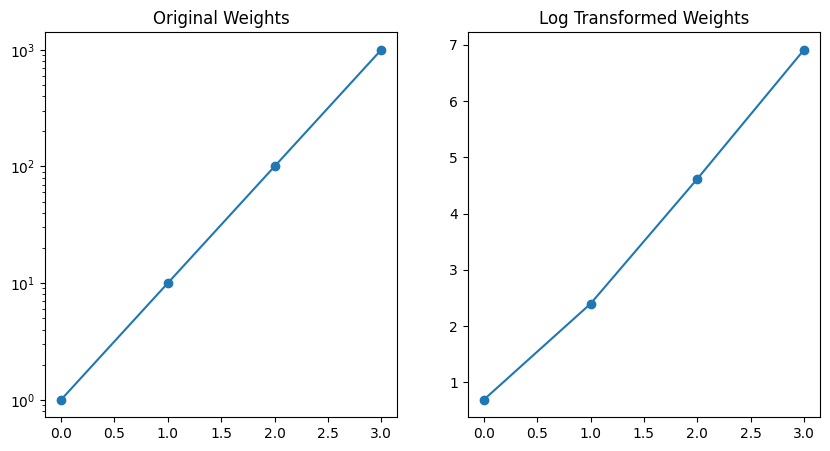

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Beispieldaten
original_weights = np.array([1, 10, 100, 1000])
log_weights = np.log1p(original_weights)

print("Original weights:", original_weights)
print("Log weights:", log_weights)

# Visualisierung
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(original_weights, 'o-')
plt.title('Original Weights')
plt.yscale('log')

plt.subplot(1,2,2)
plt.plot(log_weights, 'o-')
plt.title('Log Transformed Weights')
plt.show()

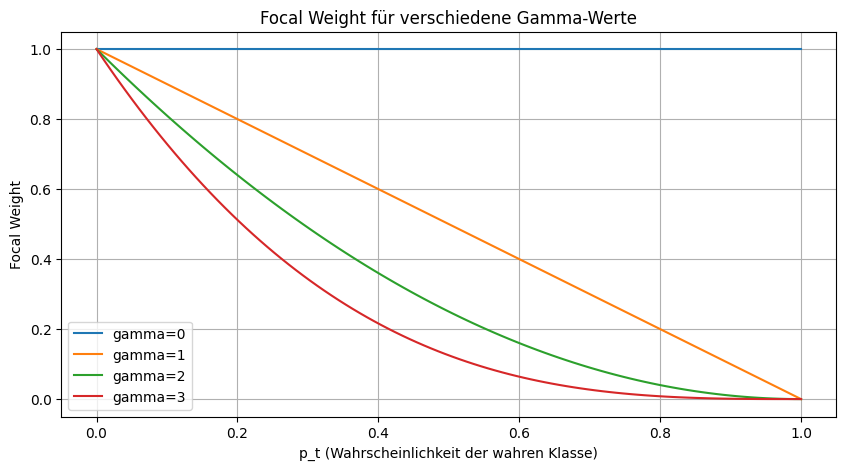

In [1]:
import matplotlib.pyplot as plt
import numpy as np

p_t = np.linspace(0, 1, 100)
gamma_values = [0, 1, 2, 3]

plt.figure(figsize=(10, 5))
for gamma in gamma_values:
    focal_weight = (1 - p_t) ** gamma
    plt.plot(p_t, focal_weight, label=f'gamma={gamma}')

plt.xlabel('p_t (Wahrscheinlichkeit der wahren Klasse)')
plt.ylabel('Focal Weight')
plt.title('Focal Weight für verschiedene Gamma-Werte')
plt.legend()
plt.grid(True)
plt.show()

In [73]:
max_sequence_length = 100
experiment_name = 'transformer_attack'

In [74]:
checkpoint_path = f'models/'
model_path = f'{checkpoint_path}earnest-sweep-18_naz2c0nx/model_epoch_78_loss_0.6290.pt'
model_path2 = f'{checkpoint_path}youthful-sweep-93_kpdn5qub/model_epoch_65_loss_0.2154.pt'



# ensure directory exists
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Das File '{model_path}' wurde nicht gefunden. " 
                          "Bitte stellen Sie sicher, dass der Pfad korrekt ist und das Verzeichnis existiert.")
# ensure directory exists
if not os.path.exists(model_path2):
    raise FileNotFoundError(f"Das File '{model_path2}' wurde nicht gefunden. " 
                          "Bitte stellen Sie sicher, dass der Pfad korrekt ist und das Verzeichnis existiert.")
   
    
    
print(model_path)
print(model_path2)

models/earnest-sweep-18_naz2c0nx/model_epoch_78_loss_0.6290.pt
models/youthful-sweep-93_kpdn5qub/model_epoch_65_loss_0.2154.pt


In [79]:
data_directory = '/home/johannes/cadets_johannes/sequences_export_benign_filetypes_path_ts_attacks'
unusable_threshold = 10
rare_threshold = 50
splits = (0.7, 0.15, 0.15) #dont rlly need here because i want to inference

max_sequence_length = 100

assert(sum(splits) == 1)

print(f'experiment parameters: \n{data_directory=} \n{unusable_threshold=} \n{rare_threshold=} \n{splits=} \n{max_sequence_length=}')

experiment parameters: 
data_directory='/home/johannes/cadets_johannes/sequences_export_benign_filetypes_path_ts_attacks' 
unusable_threshold=10 
rare_threshold=50 
splits=(0.7, 0.15, 0.15) 
max_sequence_length=100


In [80]:
total_classes = 0

# unusable classes will be removed from the dataset
unusable_classes = []
# rare classes will be oversampled
rare_classes = []

# all classes in training data (all classes - unusable classes)
classes = []

# walk all files, build unusable_classes, rare_classes
classes_occurrences = Counter()
for filename in os.listdir(data_directory):
    label = class_from_filename(filename)
    classes_occurrences[label] += 1

total_classes = len(classes_occurrences)
for label, count in classes_occurrences.items():
    if count < unusable_threshold:
        unusable_classes.append(label)
    elif count < rare_threshold:
        rare_classes.append(label)
        classes.append(label)
    else:
        classes.append(label)

print(f'Total classes: {total_classes}')
print(f'Unusable classes: {len(unusable_classes)}')
print(f'\t{unusable_classes}')
print(f'Rare classes: {len(rare_classes)}')
print(f'\t{rare_classes}')

labels_cardinality = len(set(classes))
print(f'Usable classes: {labels_cardinality}')

#labels needs to be the same.

Total classes: 134
Unusable classes: 59
	['pwd_mkdb', 'vi', 'uname', 'screen', 'stat', 'tail', 'ipfstat', 'nawk', 'ssh', 'chown', 'xz', 'pw', 'nohup', 'procstat', 'jot', 'qmgr', 'diff', 'bounce', 'pfctl', 'touch', 'minions', 'whoami', 'csh', 'syslogd', 'kldstat', 'tmux-1002', 'su', 'pwait', 'stty', 'uniq', 'mail.local', 'ping', 'limits', 'ipfw', 'df', 'ntpd', 'login', 'XIM', 'id', 'postmap', 'ipop3d', 'basename', 'pEja72mA', 'devd', 'php-fpm', 'getty', 'vUgefal', 'ifconfig', 'test', 'which', 'main', 'locate.code', 'smtp', 'cut', 'init', 'makewhatis', 'lsvfs', 'chmod', 'nice']
Rare classes: 23
	['mailwrapper', 'links', 'tr', 'less', 'env', 'tty', 'lockf', 'egrep', 'msgs', 'nginx', 'ls', 'kill', 'kenv', 'bzip2', 'ps', 'cmp', 'mail', 'expr', 'bzcat', 'sort', 'sed', 'mount', 'chkgrp']
Usable classes: 75


In [81]:
labels_set = set()

filenames_all = []

for filename in os.listdir(data_directory):
    label = class_from_filename(filename)
    if label in unusable_classes:
        continue
    labels_set.add(label)
    filenames_all.append(filename)
    




In [2]:
# build labels_map in alphabetical order
labels_map = {}
for i, label in enumerate(sorted(labels_set)):
    labels_map[label] = i
    
print(labels_map)
class_names = [name for name, idx in sorted(labels_map.items(), key=lambda x: x[1])]
print(class_names)

NameError: name 'labels_set' is not defined

In [83]:
# load data
count_files_read = 0
count_sequences_split = 0
count_splits = 0

preprocessor = Preprocessor(
    ['TYPE', 'USERNAME', 'PRED_OBJ_PATH_AUTOENC', 'PRED_OBJ_NETINFO', 'SIZE'],
    encode_map='/home/johannes/projects/transformer_bachelor/models/path_encoding_map.pkl'
)

def parse_file(filename) -> tuple[list[int], list[list[int]]]:
    """
    Parse a file and return the vectorized data. Not a pure function (calls parse_line)!
    """
    global count_files_read, count_sequences_split, count_splits

    y_list: list[int] = []
    X_list: list[list[int]] = []
    y = class_from_filename(filename)
    y = labels_map[y]
    with open(os.path.join(data_directory, filename), 'r') as f:
        lines = f.readlines()
        count_files_read += 1
    if count_files_read % 50000 == 0:
        print(f'Files read: {count_files_read}')
    X = []
    for line in lines:
        line_res = preprocessor.process(line)

        # vectorized data
        event = line_res['TYPE']
        username = line_res['USERNAME']
        pred_obj1_localip = line_res['PRED_OBJ1_LOCALIP']
        pred_obj1_localport = line_res['PRED_OBJ1_LOCALPORT']
        pred_obj1_remoteip = line_res['PRED_OBJ1_REMOTEIP']
        pred_obj1_remoteport = line_res['PRED_OBJ1_REMOTEPORT']
        pred_obj2_localip = line_res['PRED_OBJ2_LOCALIP']
        pred_obj2_localport = line_res['PRED_OBJ2_LOCALPORT']
        pred_obj2_remoteip = line_res['PRED_OBJ2_REMOTEIP']
        pred_obj2_remoteport = line_res['PRED_OBJ2_REMOTEPORT']

        # vectors
        path1 = line_res['PRED_OBJ1_PATH_AUTOENC']
        path2 = line_res['PRED_OBJ2_PATH_AUTOENC']

        # ints
        size = line_res['SIZE']

        res = [event, username, pred_obj1_localip, pred_obj1_localport, pred_obj1_remoteip, pred_obj1_remoteport, pred_obj2_localip, pred_obj2_localport, pred_obj2_remoteip, pred_obj2_remoteport, size]
        res.extend(path1)
        res.extend(path2)

        X.append(res)

    # check if sequence needs to be split
    if len(X) > max_sequence_length:
        count_sequences_split += 1
        count_splits += len(X) // max_sequence_length
        for i in range(0, len(X), max_sequence_length):
            y_list.append(y)
            X_list.append(X[i:i+max_sequence_length])
        assert len(X_list[0]) == max_sequence_length
    else:
        y_list.append(y)
        X_list.append(X)

    # transform elements to numpy arrays
    y_list = np.array(y_list)
    X_list = [np.array(x) for x in X_list]

    assert len(y_list) == len(X_list)
    return y_list, X_list


def load_data(filenames: list[str], max_samples: int = None) -> tuple[list, list]:
    """
    Load and parse data files with an optional limit on the number of samples.
    
    Args:
        filenames: List of filenames to process
        max_samples: Maximum number of samples to load (None for all samples)
    
    Returns:
        Tuple of (y_data, X_data) containing the loaded samples
    """
    y_data = []
    X_data = []
    
    for filename in filenames:
        y_list, X_list = parse_file(filename)
        
        # Check if we would exceed max_samples by adding all samples from this file
        if max_samples is not None:
            remaining_samples = max_samples - len(y_data)
            if remaining_samples <= 0:
                break
                
            # If we need only part of the samples from this file
            if len(y_list) > remaining_samples:
                y_list = y_list[:remaining_samples]
                X_list = X_list[:remaining_samples]
        
        y_data.extend(y_list)
        X_data.extend(X_list)
        
        # Print progress
        if len(y_data) % 50000 == 0:
            print(f'Loaded samples: {len(y_data)}')
            
        # Check if we've reached the sample limit
        if max_samples is not None and len(y_data) >= max_samples:
            break

    assert len(X_data) == len(y_data)
    return y_data, X_data


# Beispielaufruf:
# Alle Datensätze laden:
y_data, X_data = load_data(filenames_all)
# Oder nur die ersten 1000 Datensätze laden:
#y_data, X_data = load_data(filenames_all, max_samples=10000)

print(f'Files read: {count_files_read}')
print(f'Sequences split: {count_sequences_split}')
print(f'Splits: {count_splits}')

event_types_map = preprocessor.event_types_map
users_map = preprocessor.users_map
filetypes_map = preprocessor.filetypes_map
path_map = preprocessor.path_map
addr_map = preprocessor.addr_map
port_map = preprocessor.port_map

event_types_cardinality = len(event_types_map)
users_cardinality = len(users_map)
filetypes_cardinality = len(filetypes_map)
path_cardinality = len(path_map)
addr_cardinality = len(addr_map)
port_cardinality = len(port_map)

print(f'Event types: {event_types_cardinality}')
print(f'Users: {users_cardinality}')
print(f'Filetypes: {filetypes_cardinality}')
print(f'Address: {addr_cardinality}')
print(f'Port: {port_cardinality}')

# Nach dem Laden der Daten:
print(f'Total data points: {len(y_data)}')

AssertionError: 

In [29]:
print(f"X_train[0][0].shape: {len(X_data[0][0])}")  # Länge eines einzelnen Vektors
print(f"X_train[0].shape: {len(X_data[0])}")        # Länge der Sequenz

print(f"X_train[0][0].shape: {len(X_data[1][0])}")  # Länge eines einzelnen Vektors
print(f"X_train[0].shape: {len(X_data[0])}")        # Länge der Sequenz

lengths = set(len(seq[0]) for seq in X_data)
print(f"Unterschiedliche Vektorlängen im Training-Set: {lengths}")

X_train[0][0].shape: 107
X_train[0].shape: 2
X_train[0][0].shape: 107
X_train[0].shape: 2
Unterschiedliche Vektorlängen im Training-Set: {107}


In [30]:
# one-hot encode labels
y_data = np.eye(labels_cardinality)[y_data]

In [31]:
# Precompute identity matrices
event_eye = np.eye(event_types_cardinality)
user_eye = np.eye(users_cardinality)
addr_eye = np.eye(addr_cardinality)
port_eye = np.eye(port_cardinality)

def encode_features(sequence: np.ndarray) -> np.ndarray:
    # Initialize the output array with precomputed shapes
    encoded_seq = np.empty((len(sequence),
        event_eye.shape[1]
        + user_eye.shape[1]
        + addr_cardinality * 4
        + port_cardinality * 4
        + 48 * 2 # 48 is latent space dimension
        + 1 # size
    ))

    for i, feature_vector in enumerate(sequence):
        # one-hot
        event = event_eye[int(feature_vector[0])]
        username = user_eye[int(feature_vector[1])]
        pred_obj1_localip = addr_eye[int(feature_vector[2])]
        pred_obj1_localport = port_eye[int(feature_vector[3])]
        pred_obj1_remoteip = addr_eye[int(feature_vector[4])]
        pred_obj1_remoteport = port_eye[int(feature_vector[5])]
        pred_obj2_localip = addr_eye[int(feature_vector[6])]
        pred_obj2_localport = port_eye[int(feature_vector[7])]
        pred_obj2_remoteip = addr_eye[int(feature_vector[8])]
        pred_obj2_remoteport = port_eye[int(feature_vector[9])]
        size = feature_vector[10]
        path1 = feature_vector[10:10+48]
        path2 = feature_vector[10+48:10+48+48]

        # Concatenate all features into a single feature vector
        encoded_seq[i] = np.concatenate((event, username, pred_obj1_localip, pred_obj1_localport, pred_obj1_remoteip, pred_obj1_remoteport, pred_obj2_localip, pred_obj2_localport, pred_obj2_remoteip, pred_obj2_remoteport, [size], path1, path2))

    return encoded_seq

X_data = [ encode_features(x) for x in X_data ]


In [32]:
feature_vector_cardinality = X_data[0].shape[1]

print(f'Feature vector cardinality: {feature_vector_cardinality}')

Feature vector cardinality: 194


In [33]:
input_dim = X_data[0][0].shape[0]  # Neue Dimension nach One-Hot-Encoding
print(input_dim)
print(X_data[1].shape)

194
(20, 194)


In [34]:
from torch.utils.data import Dataset
import torch
import numpy as np

class SequenceDataset(Dataset):
    def __init__(self, X, y, fixed_length):
        self.X = X
        self.y = y
        self.fixed_length = fixed_length
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        # Einzelne Sequenz holen
        x = self.X[idx]
        y = self.y[idx]
        
        # Attention Mask erstellen (1 für echte Daten, 0 für padding)
        attention_mask = torch.ones(self.fixed_length)
        
        # Padding/Truncating
        if len(x) < self.fixed_length:
            # Mask auf 0 setzen für Padding-Bereich
            attention_mask[len(x):] = 0
            
            # Padding für die Sequenz
            padding = np.zeros((self.fixed_length - len(x), x.shape[1]))
            x = np.concatenate([x, padding], axis=0)
        else:
            x = x[:self.fixed_length]
            
        x = torch.FloatTensor(x)
        y = torch.FloatTensor([y])
        return x,  y, attention_mask



In [35]:
import torch.nn as nn
import math
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Positional Encoding Matrix berechnen
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        
        # Registrieren als Buffer (wird mit dem Modell gespeichert)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        """
        Args:
            x: Tensor mit Shape [batch_size, seq_len, d_model]
        """
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [36]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        model_dim: int,
        num_encoder_layers: int,
        num_heads: int,
        max_len: int,
        dim_feed_forward: int,
        dropout_rate: float,
        activation: str,
        padding_idx: int,
        pos_encoding_scaling: float,
        pooling_type: str,
        norm_first: bool
        
    ):
        super(TransformerEncoder, self).__init__()
        
        self.pooling_type = pooling_type.lower()
        if self.pooling_type not in ["mean", "cls"]:
            raise ValueError("pooling_type muss 'mean' oder 'cls' sein")
        
        # CLS Token nur erstellen wenn nötig
        self.cls_token = nn.Parameter(torch.randn(1, 1, model_dim)) if self.pooling_type == "cls" else None
        
        self.input_projection = nn.Linear(input_dim, model_dim)
        self.input_norm = nn.LayerNorm(model_dim)
        
        # Positionsencoding länge anpassen wenn CLS Token verwendet wird
        max_len_adjusted = max_len + 1 if self.pooling_type == "cls" else max_len
        self.pos_encoder = PositionalEncoding(model_dim, dropout_rate, max_len_adjusted)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=dim_feed_forward,
            dropout=dropout_rate,
            activation=activation,
            norm_first=norm_first,
            batch_first=True
        )
        
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers,
            norm=nn.LayerNorm(model_dim)
        )
        
        self.dropout = nn.Dropout(dropout_rate)
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, model_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, num_classes)
        )
        
        self.init_weights()
        self.pos_encoding_scaling = pos_encoding_scaling
        
    def init_weights(self):
        def _init_weights(m):
            if isinstance(m, nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
        self.apply(_init_weights)
        # CLS Token separat initialisieren falls vorhanden
        if self.cls_token is not None:
            torch.nn.init.normal_(self.cls_token, std=0.02)
    
    def mean_pooling(self, x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        mask = attention_mask.unsqueeze(-1).float()
        return torch.sum(x * mask, dim=1) / (torch.sum(mask, dim=1) + 1e-4)
    
    def cls_pooling(self, x: torch.Tensor) -> torch.Tensor:
        return x[:, 0]
        
    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor
    ) -> torch.Tensor:
        batch_size = x.shape[0]
        
        x = self.input_projection(x)
        x = self.input_norm(x)
        
        if self.pooling_type == "cls":
            # CLS Token hinzufügen
            cls_tokens = self.cls_token.expand(batch_size, -1, -1)
            x = torch.cat((cls_tokens, x), dim=1)
            
            # Attention Mask für CLS Token erweitern
            cls_mask = torch.ones((batch_size, 1), device=attention_mask.device)
            attention_mask = torch.cat((cls_mask, attention_mask), dim=1)
        
        if(self.pos_encoding_scaling == 1.0):
            x = self.pos_encoder(x)
        
        padding_mask = ~attention_mask.bool()
        
        x = self.encoder(x, src_key_padding_mask=padding_mask)
        
        # Pooling basierend auf gewählter Strategie
        if self.pooling_type == "mean":
            x = self.mean_pooling(x, attention_mask)
        else:  # cls
            x = self.cls_pooling(x)
        
        logits = self.classifier(x)
        
        return logits

In [ ]:
import torch
from torch.utils.data import DataLoader
import numpy as np

def load_model(model_path, config, device="cuda"):
    """
    Lädt das trainierte Modell mit gegebener Konfiguration
    
    Args:
        model_path: Pfad zum gespeicherten Modell
        config: Dictionary mit Modellkonfiguration, muss enthalten:
            - input_dim
            - num_classes
            - model_dim
            - num_encoder_layers
            - num_heads
            - max_len
            - dim_feed_forward
            - activation
            - pos_encoding_scaling
            - pooling_type
            - norm_first
        device: Gerät auf dem das Modell laufen soll
    """
    # Modell mit übergebener Konfiguration erstellen
    model = TransformerEncoder(
        input_dim=config['input_dim'],
        num_classes=config['num_classes'],
        model_dim=config['model_dim'],
        num_encoder_layers=config['num_encoder_layers'],
        num_heads=config['num_heads'],
        max_len=config['max_len'],
        dim_feed_forward=config['dim_feed_forward'],
        dropout_rate=0.0,  # Für Inferenz immer auf 0 setzen
        activation=config['activation'],
        padding_idx=0,
        pos_encoding_scaling=config['pos_encoding_scaling'],
        pooling_type=config['pooling_type'],
        norm_first=config['norm_first']
    )
    
    # Modell laden und in eval-Modus setzen
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model = model.to(device)
    model.eval()
    
    return model


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#Diese Config wurde aus wandb kopiert
model_config = {
    'input_dim': feature_vector_cardinality,  
    'num_classes': labels_cardinality,        
    'model_dim': 128,                        
    'num_encoder_layers': 6,                 
    'num_heads': 2,                          
    'max_len': 100,                         
    'dim_feed_forward': 4 * 128,            
    'activation': 'gelu',                    
    'pos_encoding_scaling': 1.0,          
    'pooling_type': 'mean',                  
    'norm_first': True                     
}

model_config2 = {
    'input_dim': feature_vector_cardinality,  # keeping original as it's not in YAML
    'num_classes': labels_cardinality,        # keeping original as it's not in YAML
    'model_dim': 512,                         # updated from 128 to 512
    'num_encoder_layers': 4,                  # updated from 6 to 4
    'num_heads': 16,                          # updated from 2 to 16
    'max_len': 100,                          # keeping original as it's not in YAML
    'dim_feed_forward': 4 * 512,             # updated to match new model_dim
    'activation': 'relu',                     # updated from 'gelu' to 'relu'
    'pos_encoding_scaling': 0.0,                # updated from 1.0 to 0
    'pooling_type': 'mean',                  # no change needed
    'norm_first': False                      # updated from True to False
}

# Modell laden
model = load_model(model_path, model_config, device)
model2 = load_model(model_path2, model_config2, device)

print(model2)
print("Model loaded successfully")


Using device: cuda
TransformerEncoder(
  (input_projection): Linear(in_features=194, out_features=512, bias=True)
  (input_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): LayerNorm((512,

/home/johannes/projects/transformer_bachelor/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Evaluating:   0%|          | 0/10872 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 10872/10872 [00:57<00:00, 187.65it/s]



Unique labels in dataset: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)}
Class distribution: Counter({np.int64(6): 83

/home/johannes/projects/transformer_bachelor/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Evaluation Metrics:
Accuracy: 0.2956
Precision: 0.3927
Recall: 0.2956
F1 Score: 0.2880

Generating confusion matrix...


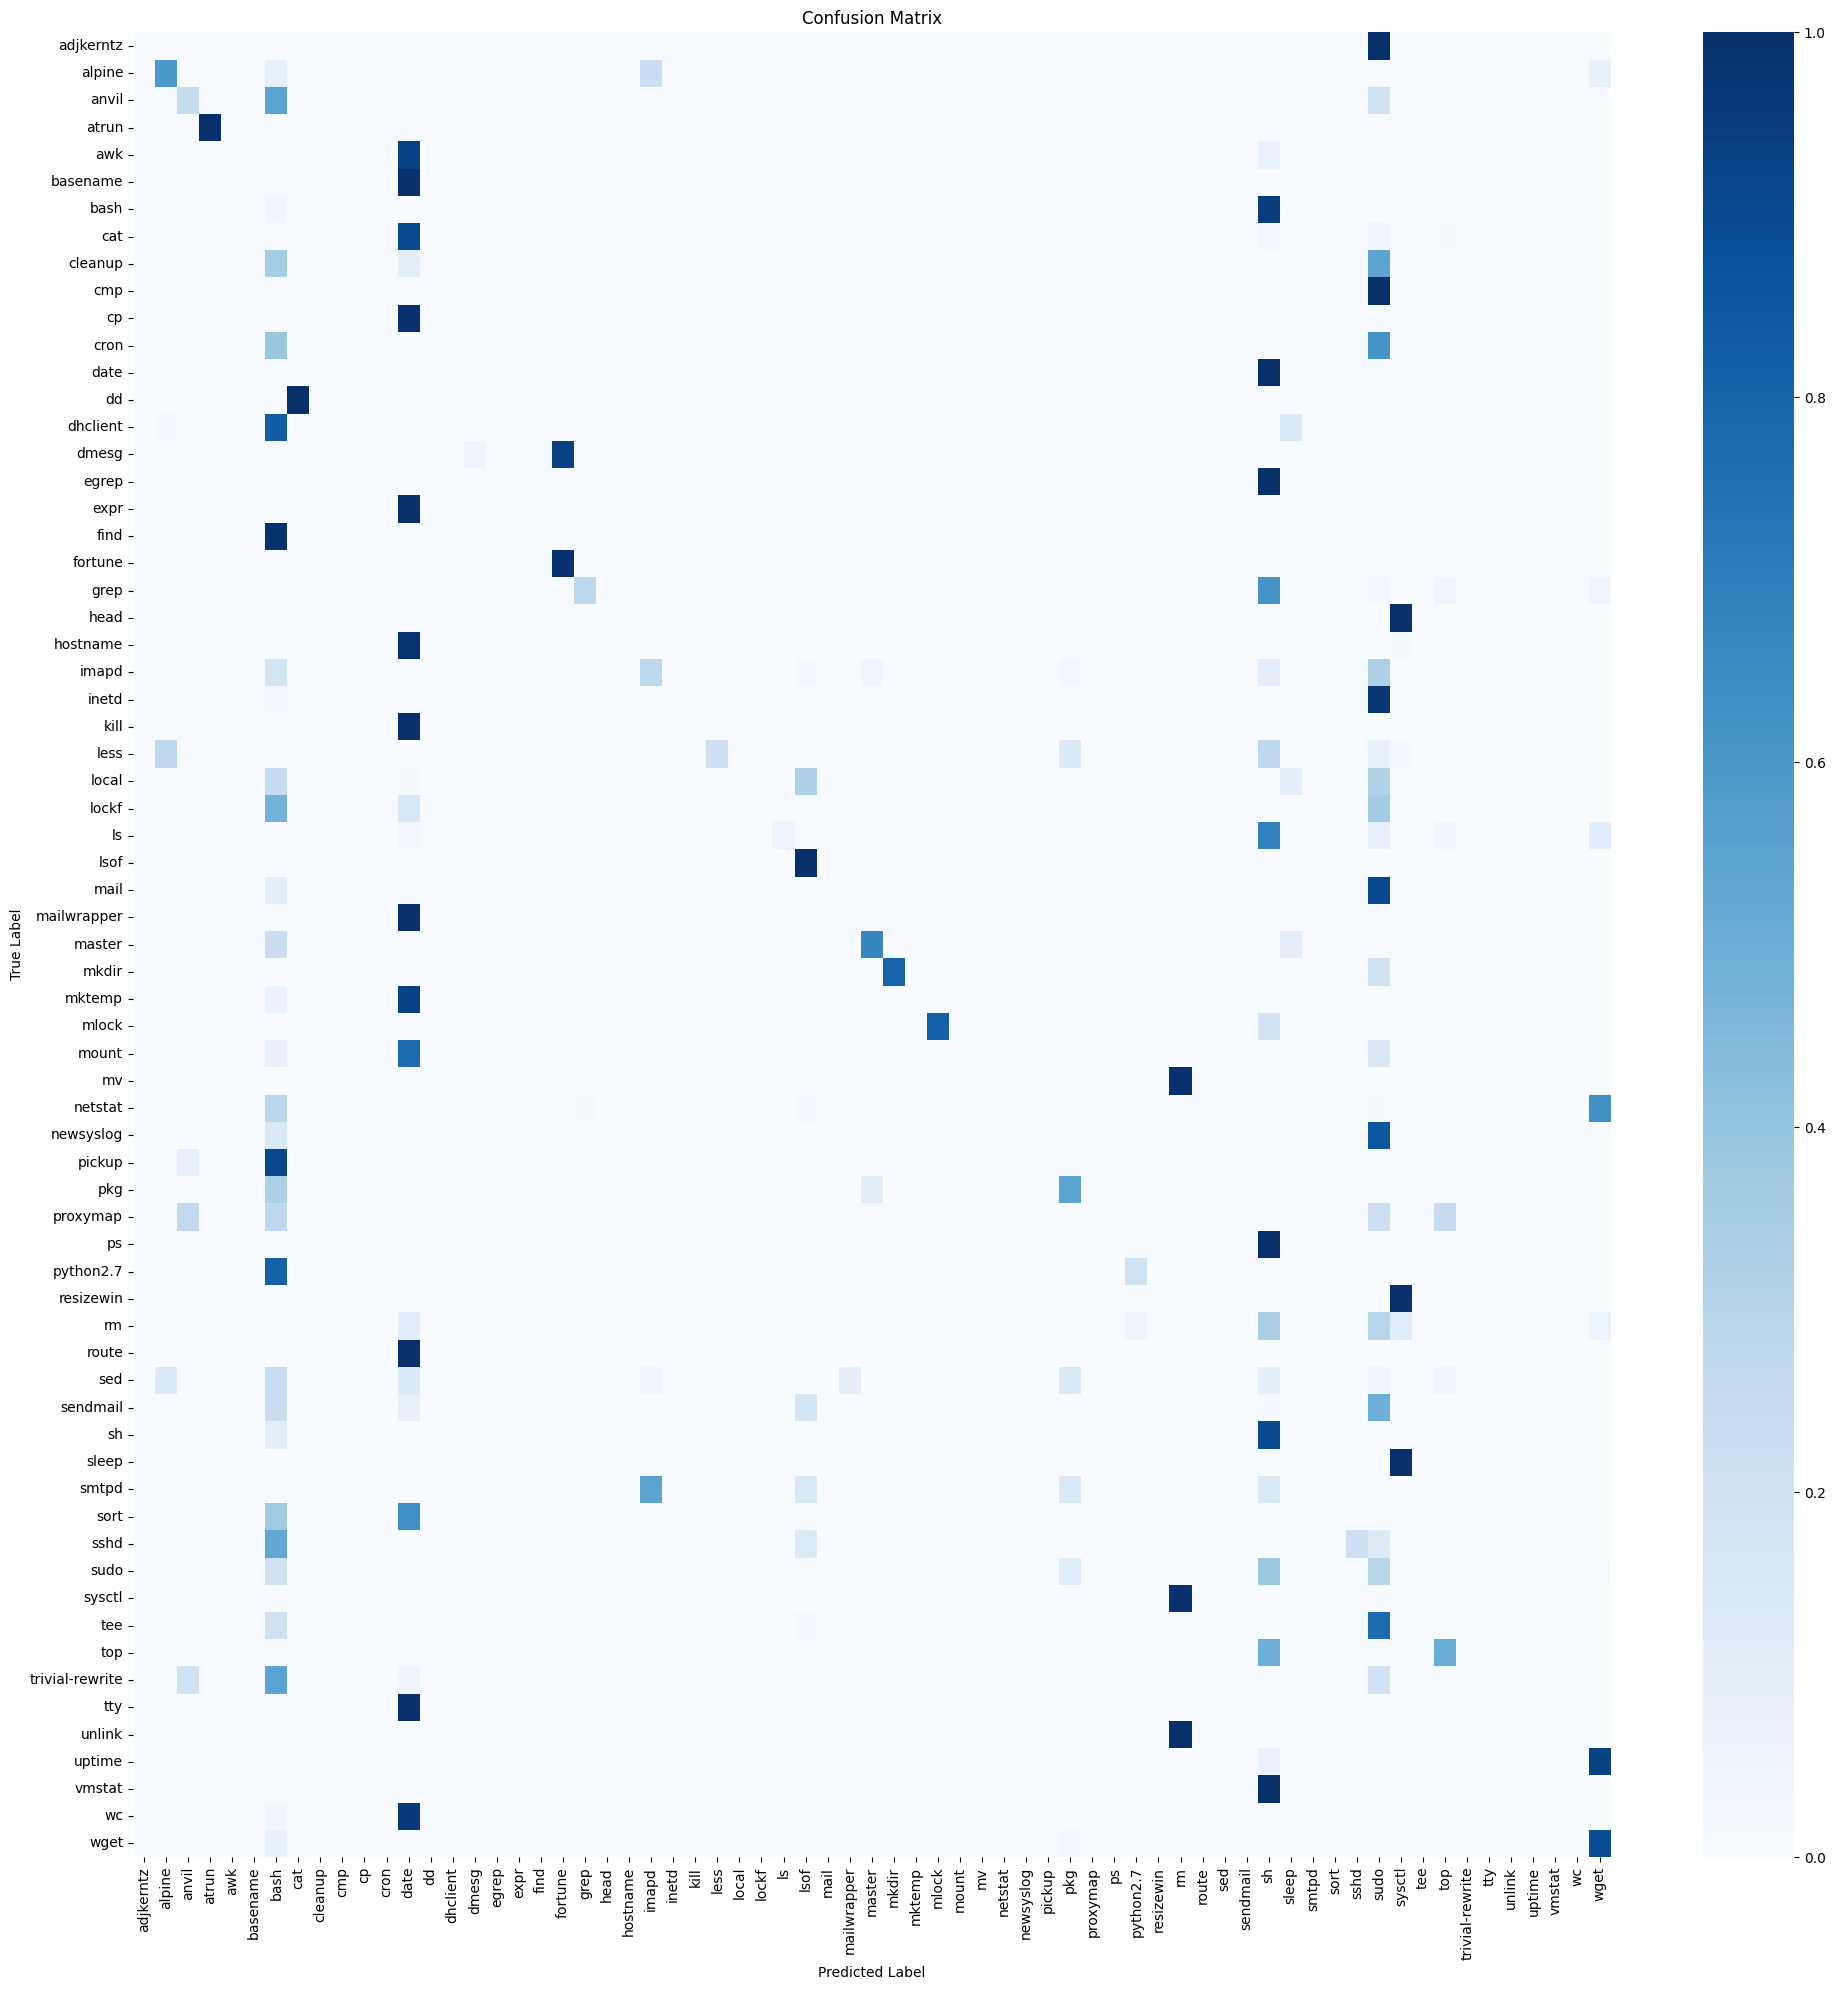

Evaluating:   0%|          | 0/10872 [00:00<?, ?it/s]/home/johannes/projects/transformer_bachelor/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
Evaluating: 100%|██████████| 10872/10872 [01:44<00:00, 104.44it/s]



Unique labels in dataset: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)}
Class distribution: Counter({np.int64(6): 83

/home/johannes/projects/transformer_bachelor/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Evaluation Metrics:
Accuracy: 0.3156
Precision: 0.3657
Recall: 0.3156
F1 Score: 0.2949

Generating confusion matrix...


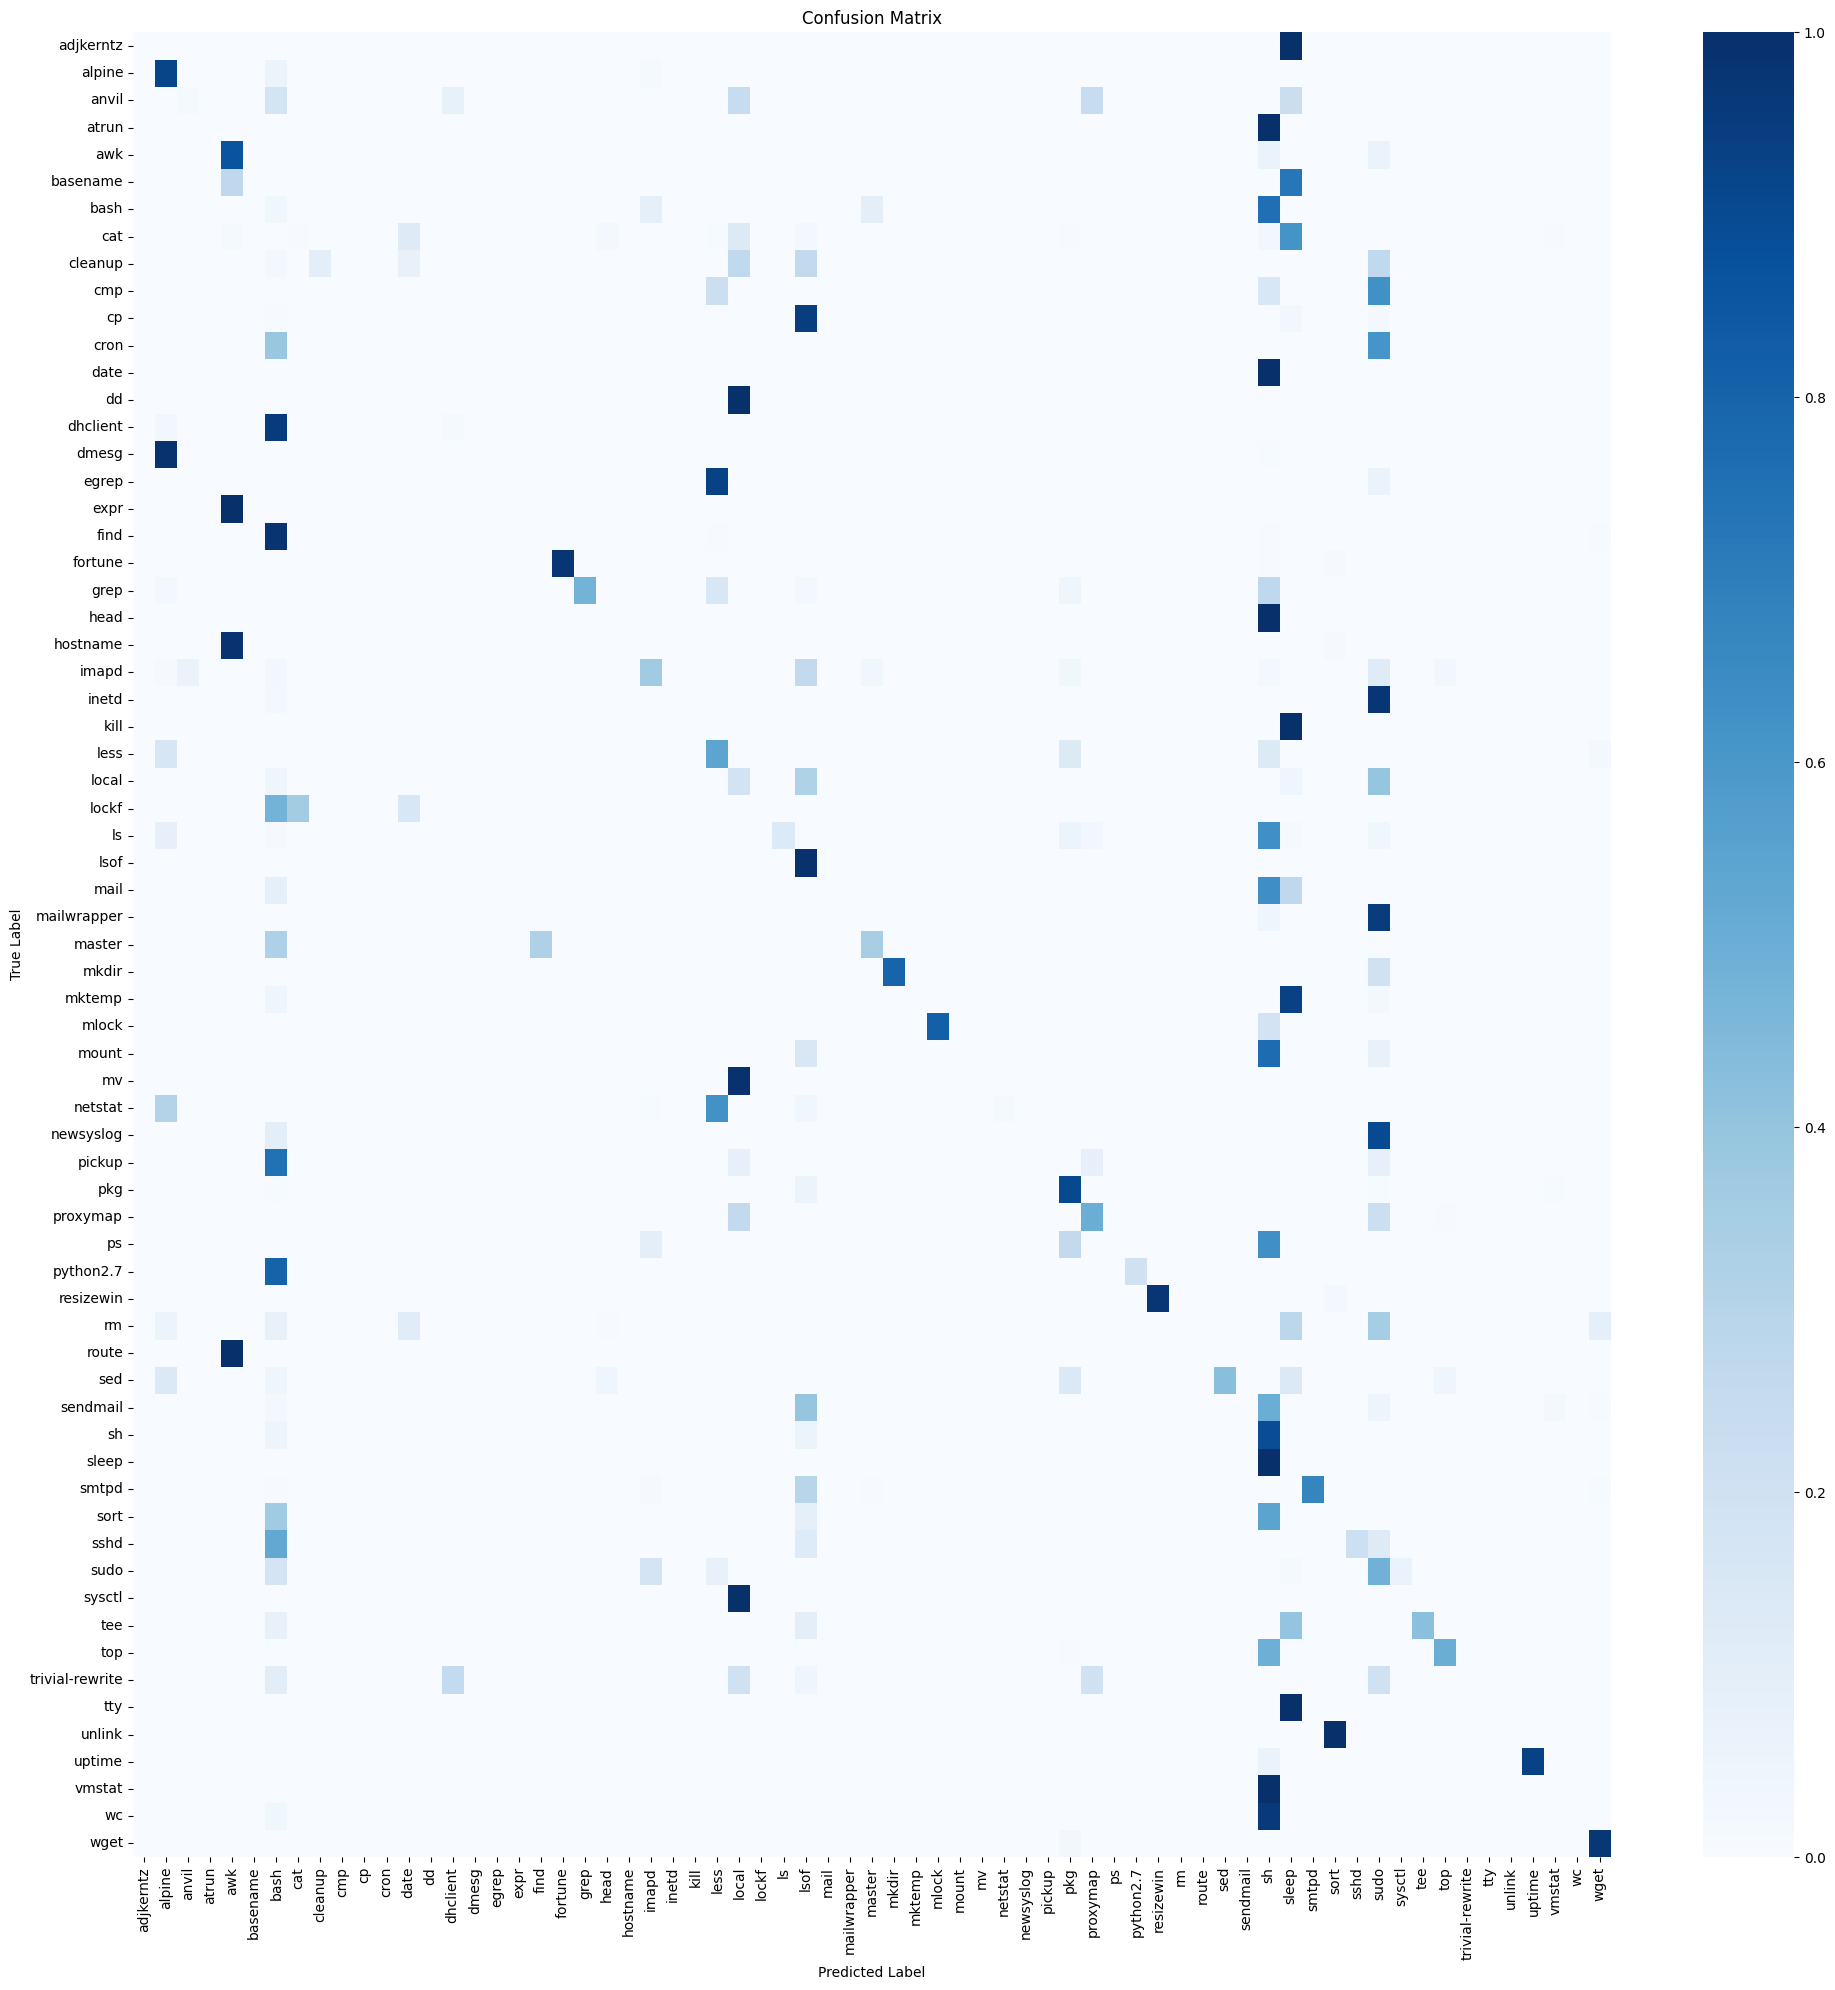

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
from collections import Counter

@torch.no_grad()
def evaluate_model(model, X_data, y_data, batch_size=32, device="cuda"):
    """
    Evaluate model's prediction performance
    
    Args:
        model: The trained transformer model
        X_data: List of input sequences
        y_data: List of one-hot encoded labels
        batch_size: Batch size for prediction
        device: Device to run predictions on
    """
    model.eval()
    correct_predictions = 0
    total_predictions = 0
    all_predictions = []
    all_labels = []
    
    # Create dataset and dataloader
    dataset = SequenceDataset(X_data, y_data, fixed_length=model_config['max_len'])
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    progress_bar = tqdm(dataloader, desc="Evaluating")
    
    for sequences, targets, attention_masks in progress_bar:
        # Move data to device
        sequences = sequences.to(device)
        targets = targets.to(device)
        attention_masks = attention_masks.to(device)
        
        # Get model predictions
        outputs = model(sequences, attention_masks)
        targets = targets.squeeze(1)
        targets = torch.argmax(targets, dim=1)
        
        # Get predictions
        predictions = torch.argmax(outputs, dim=1)
        correct_predictions += (predictions == targets).sum().item()
        total_predictions += targets.size(0)
        
        # Store predictions and labels
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())
    
    # Calculate accuracy
    accuracy = correct_predictions / total_predictions
    
    # Print class distribution information
    print(f"\nUnique labels in dataset: {set(all_labels)}")
    class_distribution = Counter(all_labels)
    print(f"Class distribution: {class_distribution}")
    
    # Compute additional metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='weighted'
    )
    
    # Compute normalized confusion matrix
    confusion_mat = confusion_matrix(all_labels, all_predictions, normalize='true')
    
    metrics = {
        'test/accuracy': accuracy,
        'test/precision': precision,
        'test/recall': recall,
        'test/f1_score': f1,
        'test/confusion_matrix': confusion_mat
    }
    
    return metrics, all_predictions, all_labels

def plot_confusion_matrix(confusion_mat, class_names):
    """
    Plot normalized confusion matrix
    """
    plt.figure(figsize=(20,20))
    sns.heatmap(
        confusion_mat,
        annot=False, 
        fmt='d', 
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f'Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    # Rotiere die Labels für bessere Lesbarkeit bei vielen Klassen
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()
    plt.close()

def print_metrics(metrics):
    """
    Print evaluation metrics in a formatted way
    """
    print("\nEvaluation Metrics:")
    print(f"Accuracy: {metrics['test/accuracy']:.4f}")
    print(f"Precision: {metrics['test/precision']:.4f}")
    print(f"Recall: {metrics['test/recall']:.4f}")
    print(f"F1 Score: {metrics['test/f1_score']:.4f}")

# Run evaluation
metrics, all_predictions, all_labels = evaluate_model(model, X_data, y_data, batch_size=32, device=device)


# Print metrics
print_metrics(metrics)

# Plot confusion matrix
print("\nGenerating confusion matrix...")
plot_confusion_matrix(metrics['test/confusion_matrix'], class_names)


# Run evaluation
metrics, all_predictions, all_labels = evaluate_model(model2, X_data, y_data, batch_size=32, device=device)


# Print metrics
print_metrics(metrics)

# Plot confusion matrix
print("\nGenerating confusion matrix...")
plot_confusion_matrix(metrics['test/confusion_matrix'], class_names)